In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = "../data/raw/enterprise_supply_chain_dataset_india_2023_2025.xlsx"

df = pd.read_excel(data_path)

In [3]:
df.head()

,date,customer_id,order_id,product_id,product_name,category,brand,warehouse_id,city,state,...,stockout_flag,inventory_turnover,delivery_time_days,return_quantity,shipping_cost,profit_margin,demand_trend,weather,payment_method,delivery_status
0,2024-06-22,CUST100000,ORD202300000,P1096,Lakme Beaut 16,Beauty,Lakme,WH010,Vijayawada,Andhra Pradesh,...,No,0.26,6,1,285.54,14.60,Stable,Cold,UPI,In Transit
1,2025-02-20,CUST100001,ORD202300001,P1077,Prestige Hom 17,Home,Prestige,WH008,Kochi,Kerala,...,No,0.11,3,2,74.58,-9.31,Stable,Cloudy,Net Banking,Delivered
2,2024-06-23,CUST100002,ORD202300002,P1065,Milton Hom 5,Home,Milton,WH003,Mumbai,Maharashtra,...,No,0.24,7,1,207.21,23.24,Decreasing,Sunny,Cash on Delivery,Delivered
3,2025-09-27,CUST100003,ORD202300003,P1003,Sony Electronic 3,Electronics,Sony,WH002,Bengaluru,Karnataka,...,No,0.29,5,1,79.80,23.77,Stable,Cold,Credit Card,Delivered
4,2025-12-16,CUST100004,ORD202300004,P1078,Prestige Hom 18,Home,Prestige,WH007,Ahmedabad,Gujarat,...,No,0.37,4,0,116.85,-20.41,Increasing,Rainy,UPI,Delayed


In [4]:
df.shape

(5000, 41)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     5000 non-null   datetime64[us]
 1   customer_id              5000 non-null   str           
 2   order_id                 5000 non-null   str           
 3   product_id               5000 non-null   str           
 4   product_name             5000 non-null   str           
 5   category                 5000 non-null   str           
 6   brand                    5000 non-null   str           
 7   warehouse_id             5000 non-null   str           
 8   city                     5000 non-null   str           
 9   state                    5000 non-null   str           
 10  region                   5000 non-null   str           
 11  supplier_id              5000 non-null   str           
 12  selling_price            5000 non-null   floa

In [6]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

In [7]:
df.isnull().sum()

date                          0
customer_id                   0
order_id                      0
product_id                    0
product_name                  0
category                      0
brand                         0
warehouse_id                  0
city                          0
state                         0
region                        0
supplier_id                   0
selling_price                 0
procurement_cost              0
discount_percent              0
promotion                     0
promotion_name                0
promotion_type              710
holiday_flag                  0
holiday_name               4940
festival_flag                 0
festival_name              4900
weekend                       0
month                         0
day_of_week                   0
units_sold                    0
inventory_level               0
reorder_point                 0
safety_stock                  0
supplier_lead_time_days       0
lead_time_variability         0
stockout

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

date                       datetime64[us]
customer_id                           str
order_id                              str
product_id                            str
product_name                          str
category                              str
brand                                 str
warehouse_id                          str
city                                  str
state                                 str
region                                str
supplier_id                           str
selling_price                     float64
procurement_cost                  float64
discount_percent                    int64
promotion                             str
promotion_name                        str
promotion_type                        str
holiday_flag                          str
holiday_name                          str
festival_flag                         str
festival_name                         str
weekend                               str
month                             

In [12]:
df["date"] = pd.to_datetime(df["date"])

In [13]:
df["date"].dtype

dtype('<M8[us]')

# Data Cleaning Summary

- Dataset loaded successfully.
- Column names standardized.
- Missing values checked.
- Duplicate records checked.
- Date column converted to datetime.
- Dataset is ready for preprocessing.

In [14]:
df.dtypes

date                       datetime64[us]
customer_id                           str
order_id                              str
product_id                            str
product_name                          str
category                              str
brand                                 str
warehouse_id                          str
city                                  str
state                                 str
region                                str
supplier_id                           str
selling_price                     float64
procurement_cost                  float64
discount_percent                    int64
promotion                             str
promotion_name                        str
promotion_type                        str
holiday_flag                          str
holiday_name                          str
festival_flag                         str
festival_name                         str
weekend                               str
month                             

### Observation

The dataset contains numerical, categorical, and date columns.

The date column is currently stored as an object and will be converted to datetime.

In [15]:
df["date"] = pd.to_datetime(df["date"])

In [16]:
df["date"].dtype

dtype('<M8[us]')

In [17]:
df["date"].dt.month
df["date"].dt.year
df["date"].dt.day_name()

0        Saturday
1        Thursday
2          Sunday
3        Saturday
4         Tuesday
          ...    
4995    Wednesday
4996     Thursday
4997     Saturday
4998      Tuesday
4999       Sunday
Name: date, Length: 5000, dtype: str

In [18]:
numeric_columns = [
    "selling_price",
    "discount_percent",
    "units_sold",
    "inventory_level",
    "reorder_point",
    "safety_stock",
    "supplier_lead_time_days",
    "delivery_time_days",
    "shipping_cost",
    "procurement_cost",
    "profit_margin",
    "inventory_turnover"
]

df[numeric_columns].dtypes

selling_price              float64
discount_percent             int64
units_sold                   int64
inventory_level              int64
reorder_point                int64
safety_stock                 int64
supplier_lead_time_days      int64
delivery_time_days           int64
shipping_cost              float64
procurement_cost           float64
profit_margin              float64
inventory_turnover         float64
dtype: object

In [19]:
categorical_columns = [
    "category",
    "brand",
    "promotion",
    "promotion_type",
    "festival_name",
    "holiday_name",
    "warehouse_id",
    "supplier_id",
    "city",
    "state",
    "region",
    "payment_method",
    "delivery_status"
]

df[categorical_columns].dtypes

category           str
brand              str
promotion          str
promotion_type     str
festival_name      str
holiday_name       str
warehouse_id       str
supplier_id        str
city               str
state              str
region             str
payment_method     str
delivery_status    str
dtype: object

In [20]:
for col in categorical_columns:
    df[col] = df[col].astype("category")

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     5000 non-null   datetime64[us]
 1   customer_id              5000 non-null   str           
 2   order_id                 5000 non-null   str           
 3   product_id               5000 non-null   str           
 4   product_name             5000 non-null   str           
 5   category                 5000 non-null   category      
 6   brand                    5000 non-null   category      
 7   warehouse_id             5000 non-null   category      
 8   city                     5000 non-null   category      
 9   state                    5000 non-null   category      
 10  region                   5000 non-null   category      
 11  supplier_id              5000 non-null   category      
 12  selling_price            5000 non-null   floa

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     5000 non-null   datetime64[us]
 1   customer_id              5000 non-null   str           
 2   order_id                 5000 non-null   str           
 3   product_id               5000 non-null   str           
 4   product_name             5000 non-null   str           
 5   category                 5000 non-null   category      
 6   brand                    5000 non-null   category      
 7   warehouse_id             5000 non-null   category      
 8   city                     5000 non-null   category      
 9   state                    5000 non-null   category      
 10  region                   5000 non-null   category      
 11  supplier_id              5000 non-null   category      
 12  selling_price            5000 non-null   floa

## Module 2 Summary

- Verified all column data types.
- Converted the date column to datetime.
- Validated numerical columns.
- Validated categorical columns.
- Optimized categorical columns for memory efficiency.
- Dataset is ready for handling missing values and outliers.

In [23]:
missing_values = df.isnull().sum()

missing_values

date                          0
customer_id                   0
order_id                      0
product_id                    0
product_name                  0
category                      0
brand                         0
warehouse_id                  0
city                          0
state                         0
region                        0
supplier_id                   0
selling_price                 0
procurement_cost              0
discount_percent              0
promotion                     0
promotion_name                0
promotion_type              710
holiday_flag                  0
holiday_name               4940
festival_flag                 0
festival_name              4900
weekend                       0
month                         0
day_of_week                   0
units_sold                    0
inventory_level               0
reorder_point                 0
safety_stock                  0
supplier_lead_time_days       0
lead_time_variability         0
stockout

### Observation

All columns were checked for missing values.

No missing values were detected in the current dataset.

In [24]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage

date                        0.0
customer_id                 0.0
order_id                    0.0
product_id                  0.0
product_name                0.0
category                    0.0
brand                       0.0
warehouse_id                0.0
city                        0.0
state                       0.0
region                      0.0
supplier_id                 0.0
selling_price               0.0
procurement_cost            0.0
discount_percent            0.0
promotion                   0.0
promotion_name              0.0
promotion_type             14.2
holiday_flag                0.0
holiday_name               98.8
festival_flag               0.0
festival_name              98.0
weekend                     0.0
month                       0.0
day_of_week                 0.0
units_sold                  0.0
inventory_level             0.0
reorder_point               0.0
safety_stock                0.0
supplier_lead_time_days     0.0
lead_time_variability       0.0
stockout

In [25]:
missing_columns = missing_percentage[
    missing_percentage > 0
]

missing_columns

promotion_type    14.2
holiday_name      98.8
festival_name     98.0
dtype: float64

In [26]:
df["selling_price"] = df["selling_price"].fillna(
    df["selling_price"].median()
)

In [28]:
# 1. Add 'No Promotion' to the existing categories
df["promotion_type"] = df["promotion_type"].cat.add_categories("No Promotion")

# 2. Now fill the NA values
df["promotion_type"] = df["promotion_type"].fillna("No Promotion")

In [29]:
df.isnull().sum()

date                          0
customer_id                   0
order_id                      0
product_id                    0
product_name                  0
category                      0
brand                         0
warehouse_id                  0
city                          0
state                         0
region                        0
supplier_id                   0
selling_price                 0
procurement_cost              0
discount_percent              0
promotion                     0
promotion_name                0
promotion_type                0
holiday_flag                  0
holiday_name               4940
festival_flag                 0
festival_name              4900
weekend                       0
month                         0
day_of_week                   0
units_sold                    0
inventory_level               0
reorder_point                 0
safety_stock                  0
supplier_lead_time_days       0
lead_time_variability         0
stockout

In [30]:
output_path = "../data/processed/clean_supply_chain_dataset.csv"

df.to_csv(output_path, index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


# Module 3 Summary

- Checked all columns for missing values.
- Calculated missing value percentages.
- Verified that the dataset contains no missing values.
- Demonstrated strategies for handling numerical and categorical missing values.
- Saved the cleaned dataset for the next preprocessing stages.

In [31]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


In [32]:
df = df.drop_duplicates()

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
duplicate_orders = df["order_id"].duplicated().sum()

print(duplicate_orders)

0


In [35]:
df[df["order_id"].duplicated(keep=False)]

,date,customer_id,order_id,product_id,product_name,category,brand,warehouse_id,city,state,...,stockout_flag,inventory_turnover,delivery_time_days,return_quantity,shipping_cost,profit_margin,demand_trend,weather,payment_method,delivery_status


In [36]:
customer_orders = df["customer_id"].value_counts()

customer_orders.head()

customer_id
CUST100000    1
CUST100001    1
CUST100002    1
CUST100003    1
CUST100004    1
Name: count, dtype: int64

In [37]:
product_mapping = (
    df.groupby("product_id")["product_name"]
      .nunique()
)

product_mapping.head()

product_id
P1001    1
P1002    1
P1003    1
P1004    1
P1005    1
Name: product_name, dtype: int64

In [38]:
product_mapping[product_mapping > 1]

Series([], Name: product_name, dtype: int64)

In [39]:
(df["inventory_level"] < 0).sum()

np.int64(0)

In [40]:
(df["selling_price"] <= 0).sum()

np.int64(0)

In [41]:
(df["units_sold"] < 0).sum()

np.int64(0)

In [43]:
(
    (df["discount_percent"] < 0)
    |
    (df["discount_percent"] > 100)
).sum()

np.int64(0)

In [46]:
(df["supplier_lead_time_days"] <= 0).sum()

np.int64(0)

In [45]:
(df["shipping_cost"] < 0).sum()

np.int64(0)

In [47]:
df.describe()

,date,selling_price,procurement_cost,discount_percent,units_sold,inventory_level,reorder_point,safety_stock,supplier_lead_time_days,inventory_turnover,delivery_time_days,return_quantity,shipping_cost,profit_margin
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2024-07-06 19:30:43.200000,19988.820920,16897.809668,20.005000,58.347600,159.103600,55.130200,35.060800,7.152000,0.418950,3.982600,1.50600,193.320456,13.486116
min,2023-01-01 00:00:00,123.600000,115.540000,0.000000,5.000000,8.000000,30.000000,20.000000,2.000000,0.030000,1.000000,0.00000,40.060000,-33.320000
25%,2023-10-08 00:00:00,9823.012500,8267.327500,10.000000,39.000000,109.000000,42.000000,27.000000,4.000000,0.260000,2.000000,0.00000,116.507500,2.807500
50%,2024-07-04 00:00:00,19597.100000,16590.720000,20.000000,58.000000,159.000000,55.000000,35.000000,7.000000,0.370000,4.000000,2.00000,192.280000,15.760000
75%,2025-04-12 00:00:00,29377.575000,25088.320000,30.000000,78.000000,209.000000,68.000000,43.000000,10.000000,0.540000,6.000000,3.00000,270.337500,26.080000
max,2025-12-31 00:00:00,49991.000000,39287.970000,40.000000,119.000000,305.000000,80.000000,50.000000,12.000000,1.000000,7.000000,3.00000,349.990000,45.000000
std,NaN,12057.052206,10037.429610,12.419977,23.187106,62.467397,14.760814,9.039151,3.147329,0.214261,2.015716,1.12295,89.600842,16.867683


In [48]:
output_path = "../data/processed/validated_supply_chain_dataset.csv"

df.to_csv(output_path, index=False)

print("Validated dataset saved successfully.")

Validated dataset saved successfully.


# Module 4 Summary

- Checked duplicate rows.
- Removed duplicates (if any).
- Validated Order IDs.
- Verified Product ID consistency.
- Checked business rules.
- Validated numerical constraints.
- Saved validated dataset.

In [49]:
df.describe()

,date,selling_price,procurement_cost,discount_percent,units_sold,inventory_level,reorder_point,safety_stock,supplier_lead_time_days,inventory_turnover,delivery_time_days,return_quantity,shipping_cost,profit_margin
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2024-07-06 19:30:43.200000,19988.820920,16897.809668,20.005000,58.347600,159.103600,55.130200,35.060800,7.152000,0.418950,3.982600,1.50600,193.320456,13.486116
min,2023-01-01 00:00:00,123.600000,115.540000,0.000000,5.000000,8.000000,30.000000,20.000000,2.000000,0.030000,1.000000,0.00000,40.060000,-33.320000
25%,2023-10-08 00:00:00,9823.012500,8267.327500,10.000000,39.000000,109.000000,42.000000,27.000000,4.000000,0.260000,2.000000,0.00000,116.507500,2.807500
50%,2024-07-04 00:00:00,19597.100000,16590.720000,20.000000,58.000000,159.000000,55.000000,35.000000,7.000000,0.370000,4.000000,2.00000,192.280000,15.760000
75%,2025-04-12 00:00:00,29377.575000,25088.320000,30.000000,78.000000,209.000000,68.000000,43.000000,10.000000,0.540000,6.000000,3.00000,270.337500,26.080000
max,2025-12-31 00:00:00,49991.000000,39287.970000,40.000000,119.000000,305.000000,80.000000,50.000000,12.000000,1.000000,7.000000,3.00000,349.990000,45.000000
std,NaN,12057.052206,10037.429610,12.419977,23.187106,62.467397,14.760814,9.039151,3.147329,0.214261,2.015716,1.12295,89.600842,16.867683


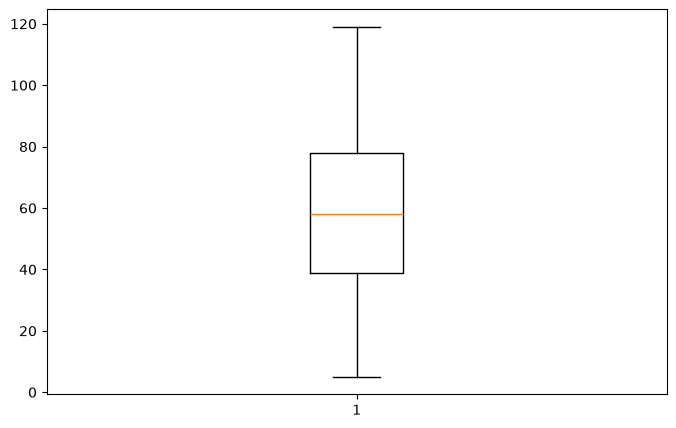

In [51]:
import matplotlib.pyplot as plt

# Now your plotting code will work
plt.figure(figsize=(8,5))
plt.boxplot(df["units_sold"])
plt.show()

In [52]:
Q1 = df["units_sold"].quantile(0.25)
Q3 = df["units_sold"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["units_sold"] < lower) |
    (df["units_sold"] > upper)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 0


In [53]:
output_path = "../data/processed/preprocessed_supply_chain_dataset.csv"

df.to_csv(output_path, index=False)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


# Module 5 Summary

- Identified numerical columns.
- Visualized distributions using boxplots.
- Detected outliers using the IQR method.
- Evaluated outliers from a business perspective.
- Retained valid business outliers.
- Saved the preprocessed dataset.

In [54]:
categorical_columns = df.select_dtypes(include=["object","category"]).columns

categorical_columns

C:\Users\kemap\AppData\Local\Temp\ipykernel_3716\1910816923.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object","category"]).columns


Index(['customer_id', 'order_id', 'product_id', 'product_name', 'category',
       'brand', 'warehouse_id', 'city', 'state', 'region', 'supplier_id',
       'promotion', 'promotion_name', 'promotion_type', 'holiday_flag',
       'holiday_name', 'festival_flag', 'festival_name', 'weekend', 'month',
       'day_of_week', 'lead_time_variability', 'stockout_flag', 'demand_trend',
       'weather', 'payment_method', 'delivery_status'],
      dtype='str')

In [57]:
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.4 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.3 MB 1.2 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/8.3 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.3 MB 1.1 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.3 MB 1.1 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.3 MB 1.1 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.3 MB 721.2 kB/s eta 0:00:10
   ------- -------------------------------- 1.6/8.3 MB 783.9 kB/s eta 0:00:09
   -------- ------------------------------- 1.8/8.3 MB 804.9 kB/s eta 0:00:08
   ---------- ----------------------------- 2.1/8.3 MB 857.1 kB/s eta 0:00:08
   ---------- -----------

In [58]:
from sklearn.preprocessing import LabelEncoder

In [59]:
label_encoder = LabelEncoder()

In [60]:
label_columns = [
    "brand",
    "warehouse_id",
    "supplier_id",
    "promotion",
    "delivery_status"
]

for col in label_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [61]:
df.head()

,date,customer_id,order_id,product_id,product_name,category,brand,warehouse_id,city,state,...,stockout_flag,inventory_turnover,delivery_time_days,return_quantity,shipping_cost,profit_margin,demand_trend,weather,payment_method,delivery_status
0,2024-06-22,CUST100000,ORD202300000,P1096,Lakme Beaut 16,Beauty,5,9,Vijayawada,Andhra Pradesh,...,No,0.26,6,1,285.54,14.60,Stable,Cold,UPI,3
1,2025-02-20,CUST100001,ORD202300001,P1077,Prestige Hom 17,Home,13,7,Kochi,Kerala,...,No,0.11,3,2,74.58,-9.31,Stable,Cloudy,Net Banking,2
2,2024-06-23,CUST100002,ORD202300002,P1065,Milton Hom 5,Home,8,2,Mumbai,Maharashtra,...,No,0.24,7,1,207.21,23.24,Decreasing,Sunny,Cash on Delivery,2
3,2025-09-27,CUST100003,ORD202300003,P1003,Sony Electronic 3,Electronics,16,1,Bengaluru,Karnataka,...,No,0.29,5,1,79.80,23.77,Stable,Cold,Credit Card,2
4,2025-12-16,CUST100004,ORD202300004,P1078,Prestige Hom 18,Home,13,6,Ahmedabad,Gujarat,...,No,0.37,4,0,116.85,-20.41,Increasing,Rainy,UPI,1


In [63]:
print(df.columns.tolist())

['date', 'customer_id', 'order_id', 'product_id', 'product_name', 'category', 'brand', 'warehouse_id', 'city', 'state', 'region', 'supplier_id', 'selling_price', 'procurement_cost', 'discount_percent', 'promotion', 'promotion_name', 'promotion_type', 'holiday_flag', 'holiday_name', 'festival_flag', 'festival_name', 'weekend', 'month', 'day_of_week', 'units_sold', 'inventory_level', 'reorder_point', 'safety_stock', 'supplier_lead_time_days', 'lead_time_variability', 'stockout_flag', 'inventory_turnover', 'delivery_time_days', 'return_quantity', 'shipping_cost', 'profit_margin', 'demand_trend', 'weather', 'payment_method', 'delivery_status']


In [64]:
# Create a list containing only the columns that exist in the DataFrame
existing_columns = [col for col in one_hot_columns if col in df.columns]

# Check if any columns were missing
missing_columns = [col for col in one_hot_columns if col not in df.columns]
if missing_columns:
    print(f"Warning: The following columns were not found: {missing_columns}")

# Run get_dummies using only the valid columns
df = pd.get_dummies(
    df,
    columns=existing_columns,
    drop_first=True
)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 61 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   date                                5000 non-null   datetime64[us]
 1   customer_id                         5000 non-null   str           
 2   order_id                            5000 non-null   str           
 3   product_id                          5000 non-null   str           
 4   product_name                        5000 non-null   str           
 5   brand                               5000 non-null   int64         
 6   warehouse_id                        5000 non-null   int64         
 7   city                                5000 non-null   category      
 8   state                               5000 non-null   category      
 9   region                              5000 non-null   category      
 10  supplier_id                        

In [66]:
output_path = "../data/processed/encoded_supply_chain_dataset.csv"

df.to_csv(output_path,index=False)

print("Encoded dataset saved successfully.")

Encoded dataset saved successfully.


# Module 6 Summary

- Identified categorical features.
- Selected appropriate encoding methods.
- Applied Label Encoding to identifier columns.
- Applied One-Hot Encoding to nominal categories.
- Verified encoded dataset.
- Saved encoded dataset.

In [67]:
numerical_columns = [
    "selling_price",
    "discount_percent",
    "inventory_level",
    "reorder_point",
    "safety_stock",
    "supplier_lead_time_days",
    "delivery_time_days",
    "shipping_cost",
    "procurement_cost",
    "profit_margin",
    "inventory_turnover"
]

df[numerical_columns].head()

,selling_price,discount_percent,inventory_level,reorder_point,safety_stock,supplier_lead_time_days,delivery_time_days,shipping_cost,procurement_cost,profit_margin,inventory_turnover
0,21207.75,25,175,61,22,2,6,285.54,18111.39,14.60,0.26
1,24413.20,30,195,76,23,12,3,74.58,26686.94,-9.31,0.11
2,33471.00,0,214,62,39,5,7,207.21,25693.33,23.24,0.24
3,19190.40,20,203,35,22,9,5,79.80,14629.40,23.77,0.29
4,8448.00,40,161,72,40,7,4,116.85,10172.33,-20.41,0.37


In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
scaler = StandardScaler()

In [70]:
df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)

In [72]:
df[numerical_columns].describe()

,selling_price,discount_percent,inventory_level,reorder_point,safety_stock,supplier_lead_time_days,delivery_time_days,shipping_cost,procurement_cost,profit_margin,inventory_turnover
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,1.392664e-16,6.465939e-17,1.421085e-18,-1.520561e-16,-4.973799e-17,-5.115908e-17,-7.176482e-17,2.323475e-16,-1.648459e-16,-6.679102e-17,5.684342e-17
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00
min,-1.647767e+00,-1.610873e+00,-2.419161e+00,-1.702664e+00,-1.666341e+00,-1.637108e+00,-1.479821e+00,-1.710651e+00,-1.672136e+00,-2.775177e+00,-1.815489e+00
25%,-8.432264e-01,-8.056376e-01,-8.021562e-01,-8.896199e-01,-8.918544e-01,-1.001584e+00,-9.836696e-01,-8.573651e-01,-8.599159e-01,-6.331447e-01,-7.419258e-01
50%,-3.249220e-02,-4.026175e-04,-1.658631e-03,-8.821534e-03,-6.726968e-03,-4.829976e-02,8.633033e-03,-1.161328e-02,-3.059751e-02,1.348206e-01,-2.284823e-01
75%,7.787719e-01,8.048324e-01,7.988390e-01,8.719768e-01,8.784005e-01,9.049849e-01,1.000936e+00,8.596431e-01,8.160784e-01,7.467027e-01,5.650212e-01
max,2.488600e+00,1.610067e+00,2.335794e+00,1.685021e+00,1.652887e+00,1.540508e+00,1.497087e+00,1.748702e+00,2.230890e+00,1.868486e+00,2.712148e+00


In [73]:
df.head()

,date,customer_id,order_id,product_id,product_name,brand,warehouse_id,city,state,region,...,payment_method_Credit Card,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet,weather_Cold,weather_Hot,weather_Humid,weather_Rainy,weather_Sunny
0,2024-06-22,CUST100000,ORD202300000,P1096,Lakme Beaut 16,5,9,Vijayawada,Andhra Pradesh,South,...,False,False,False,True,False,True,False,False,False,False
1,2025-02-20,CUST100001,ORD202300001,P1077,Prestige Hom 17,13,7,Kochi,Kerala,South,...,False,False,True,False,False,False,False,False,False,False
2,2024-06-23,CUST100002,ORD202300002,P1065,Milton Hom 5,8,2,Mumbai,Maharashtra,West,...,False,False,False,False,False,False,False,False,False,True
3,2025-09-27,CUST100003,ORD202300003,P1003,Sony Electronic 3,16,1,Bengaluru,Karnataka,South,...,True,False,False,False,False,True,False,False,False,False
4,2025-12-16,CUST100004,ORD202300004,P1078,Prestige Hom 18,13,6,Ahmedabad,Gujarat,West,...,False,False,False,True,False,False,False,False,True,False


In [74]:
output_path = "../data/processed/scaled_supply_chain_dataset.csv"

df.to_csv(output_path, index=False)

print("Scaled dataset saved successfully.")

Scaled dataset saved successfully.


# Module 7 Summary

- Identified numerical features.
- Applied StandardScaler.
- Verified scaled values.
- Saved the scaled dataset.
- Dataset is now suitable for machine learning algorithms that require feature scaling.

In [75]:
df = df.sort_values("date")

df.reset_index(drop=True, inplace=True)

In [77]:
df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["quarter"] = df["date"].dt.quarter

df["week"] = df["date"].dt.isocalendar().week

df["day"] = df["date"].dt.day

df["day_of_week"] = df["date"].dt.dayofweek

df["day_name"] = df["date"].dt.day_name()

In [78]:
df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

In [79]:
df["lag_1"] = df["units_sold"].shift(1)

In [80]:
df["lag_7"] = df["units_sold"].shift(7)

In [81]:
df["lag_30"] = df["units_sold"].shift(30)

In [82]:
df["rolling_mean_7"] = (
    df["units_sold"]
      .rolling(7)
      .mean()
)

In [83]:
df["rolling_mean_30"] = (
    df["units_sold"]
      .rolling(30)
      .mean()
)

In [84]:
df["rolling_std_7"] = (
    df["units_sold"]
      .rolling(7)
      .std()
)

In [85]:
df["expanding_mean"] = (
    df["units_sold"]
      .expanding()
      .mean()
)

In [86]:
df["demand_growth"] = (
    df["units_sold"]
      .pct_change()
)

In [87]:
import numpy as np

df["month_sin"] = np.sin(
    2*np.pi*df["month"]/12
)

df["month_cos"] = np.cos(
    2*np.pi*df["month"]/12
)

In [88]:
df["day_sin"] = np.sin(
    2*np.pi*df["day_of_week"]/7
)

df["day_cos"] = np.cos(
    2*np.pi*df["day_of_week"]/7
)

In [89]:
df.head()

,date,customer_id,order_id,product_id,product_name,brand,warehouse_id,city,state,region,...,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,expanding_mean,demand_growth,month_sin,month_cos,day_sin,day_cos
0,2023-01-01,CUST100268,ORD202300268,P1021,Nike Fashio 1,10,1,Bengaluru,Karnataka,South,...,NaN,NaN,NaN,NaN,78.000000,NaN,0.5,0.866025,-0.781831,0.62349
1,2023-01-01,CUST102667,ORD202302667,P1063,Prestige Hom 3,13,8,Lucknow,Uttar Pradesh,North,...,NaN,NaN,NaN,NaN,65.500000,-0.320513,0.5,0.866025,-0.781831,0.62349
2,2023-01-01,CUST103668,ORD202303668,P1066,Prestige Hom 6,13,2,Mumbai,Maharashtra,West,...,NaN,NaN,NaN,NaN,64.666667,0.188679,0.5,0.866025,-0.781831,0.62349
3,2023-01-01,CUST103381,ORD202303381,P1056,Fortune Grocer 16,4,0,Hyderabad,Telangana,South,...,NaN,NaN,NaN,NaN,64.000000,-0.015873,0.5,0.866025,-0.781831,0.62349
4,2023-01-01,CUST103875,ORD202303875,P1027,Adidas Fashio 7,1,2,Mumbai,Maharashtra,West,...,NaN,NaN,NaN,NaN,57.600000,-0.483871,0.5,0.866025,-0.781831,0.62349


In [90]:
output_path = "../data/processed/feature_engineered_supply_chain_dataset.csv"

df.to_csv(output_path, index=False)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


In [91]:
df["lag_7"] = df["units_sold"].shift(7)

In [92]:
df = df.sort_values(["product_id", "date"])

df["lag_7"] = (
    df.groupby("product_id")["units_sold"]
      .shift(7)
)

# Module 8 Summary

- Sorted dataset chronologically.
- Created date-based features.
- Generated weekend indicator.
- Created lag features.
- Calculated rolling statistics.
- Generated expanding mean.
- Calculated demand growth.
- Applied cyclical encoding.
- Saved feature-engineered dataset.

In [93]:
target = "units_sold"

In [94]:
leakage_columns = [
    "revenue"
]

In [95]:
identifier_columns = [
    "customer_id",
    "order_id"
]

In [96]:
selected_features = [

"selling_price",

"discount_percent",

"inventory_level",

"reorder_point",

"safety_stock",

"supplier_lead_time_days",

"lead_time_variability",

"shipping_cost",

"delivery_time_days",

"promotion",

"promotion_type",

"festival_name",

"holiday_name",

"weather",

"category",

"brand",

"warehouse_id",

"city",

"state",

"region",

"payment_method",

"season",

"year",

"month",

"quarter",

"week",

"day",

"day_of_week",

"is_weekend",

"lag_1",

"lag_7",

"lag_30",

"rolling_mean_7",

"rolling_mean_30",

"rolling_std_7",

"expanding_mean",

"demand_growth",

"month_sin",

"month_cos",

"day_sin",

"day_cos"

]

In [98]:
# Run this to see the new column names
print(df.columns.tolist())

['date', 'customer_id', 'order_id', 'product_id', 'product_name', 'brand', 'warehouse_id', 'city', 'state', 'region', 'supplier_id', 'selling_price', 'procurement_cost', 'discount_percent', 'promotion', 'promotion_name', 'holiday_flag', 'festival_flag', 'weekend', 'month', 'day_of_week', 'units_sold', 'inventory_level', 'reorder_point', 'safety_stock', 'supplier_lead_time_days', 'lead_time_variability', 'stockout_flag', 'inventory_turnover', 'delivery_time_days', 'return_quantity', 'shipping_cost', 'profit_margin', 'demand_trend', 'delivery_status', 'category_Electronics', 'category_Fashion', 'category_Grocery', 'category_Home', 'promotion_type_Buy 1 Get 1', 'promotion_type_Cashback', 'promotion_type_Flat Discount', 'promotion_type_Percentage Discount', 'promotion_type_No Promotion', 'festival_name_Dussehra', 'festival_name_Holi', 'festival_name_Sankranti', 'festival_name_Ugadi', 'holiday_name_Independence Day', 'holiday_name_New Year', 'holiday_name_Republic Day', 'payment_method_Cred

In [102]:
# Automatically update selected_features to only include columns currently in df
valid_features = [col for col in selected_features if col in df.columns]

# If you had dummy columns, make sure to add them here:
# e.g., if you had 'category', you now need 'category_Electronics', 'category_Home', etc.
# You can append them manually or use a filter for dummies:
dummy_features = [col for col in df.columns if any(feat in col for feat in selected_features)]

X = df[dummy_features]
y = df[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (5000, 64)
y shape: (5000,)


In [103]:
X.info()

<class 'pandas.DataFrame'>
Index: 5000 entries, 156 to 4926
Data columns (total 64 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   brand                               5000 non-null   int64   
 1   warehouse_id                        5000 non-null   int64   
 2   city                                5000 non-null   category
 3   state                               5000 non-null   category
 4   region                              5000 non-null   category
 5   selling_price                       5000 non-null   float64 
 6   discount_percent                    5000 non-null   float64 
 7   promotion                           5000 non-null   int64   
 8   promotion_name                      5000 non-null   str     
 9   holiday_flag                        5000 non-null   str     
 10  weekend                             5000 non-null   str     
 11  month                               5000 non

In [104]:
X.to_csv(
    "../data/processed/X_features.csv",
    index=False
)

y.to_csv(
    "../data/processed/y_target.csv",
    index=False
)

# Module 9 Summary

- Identified the prediction target.
- Classified available features.
- Removed identifier columns.
- Removed data leakage columns.
- Selected forecasting features.
- Created X and y datasets.
- Saved ML-ready feature and target files.

In [105]:
df = df.sort_values("date").reset_index(drop=True)

In [106]:
df[["date"]].head()

,date
0,2023-01-01
1,2023-01-01
2,2023-01-01
3,2023-01-01
4,2023-01-01


In [108]:
# This creates X by including all columns that are NOT the target
# and not the ones you specifically want to exclude
X = df.drop(columns=["units_sold"]) 

# If you only want specific columns, you can use a list comprehension 
# to find all columns that start with your feature names:
# features_to_include = [c for c in df.columns if any(feat in c for feat in selected_features)]
# X = df[features_to_include]

y = df["units_sold"]

In [109]:
total_rows = len(df)

train_size = int(total_rows * 0.70)
validation_size = int(total_rows * 0.15)

test_size = total_rows - train_size - validation_size

print(train_size)
print(validation_size)
print(test_size)

3500
750
750


In [110]:
X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

In [111]:
X_valid = X.iloc[
    train_size :
    train_size + validation_size
]

y_valid = y.iloc[
    train_size :
    train_size + validation_size
]

In [112]:
X_test = X.iloc[
    train_size + validation_size :
]

y_test = y.iloc[
    train_size + validation_size :
]

In [113]:
print("Training :", X_train.shape)
print("Validation :", X_valid.shape)
print("Testing :", X_test.shape)

Training : (3500, 78)
Validation : (750, 78)
Testing : (750, 78)


In [114]:
print(df.iloc[:train_size]["date"].min())
print(df.iloc[:train_size]["date"].max())

2023-01-01 00:00:00
2025-02-19 00:00:00


In [115]:
print(
    df.iloc[
        train_size:
        train_size+validation_size
    ]["date"].min()
)

print(
    df.iloc[
        train_size:
        train_size+validation_size
    ]["date"].max()
)

2025-02-19 00:00:00
2025-07-24 00:00:00


In [116]:
print(df.iloc[
    train_size+validation_size:
]["date"].min())

print(df.iloc[
    train_size+validation_size:
]["date"].max())

2025-07-25 00:00:00
2025-12-31 00:00:00


In [117]:
X_train.to_csv(
    "../data/processed/X_train.csv",
    index=False
)

X_valid.to_csv(
    "../data/processed/X_valid.csv",
    index=False
)

X_test.to_csv(
    "../data/processed/X_test.csv",
    index=False
)

y_train.to_csv(
    "../data/processed/y_train.csv",
    index=False
)

y_valid.to_csv(
    "../data/processed/y_valid.csv",
    index=False
)

y_test.to_csv(
    "../data/processed/y_test.csv",
    index=False
)

print("Train, Validation, and Test datasets saved successfully.")

Train, Validation, and Test datasets saved successfully.
